In [9]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [11]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

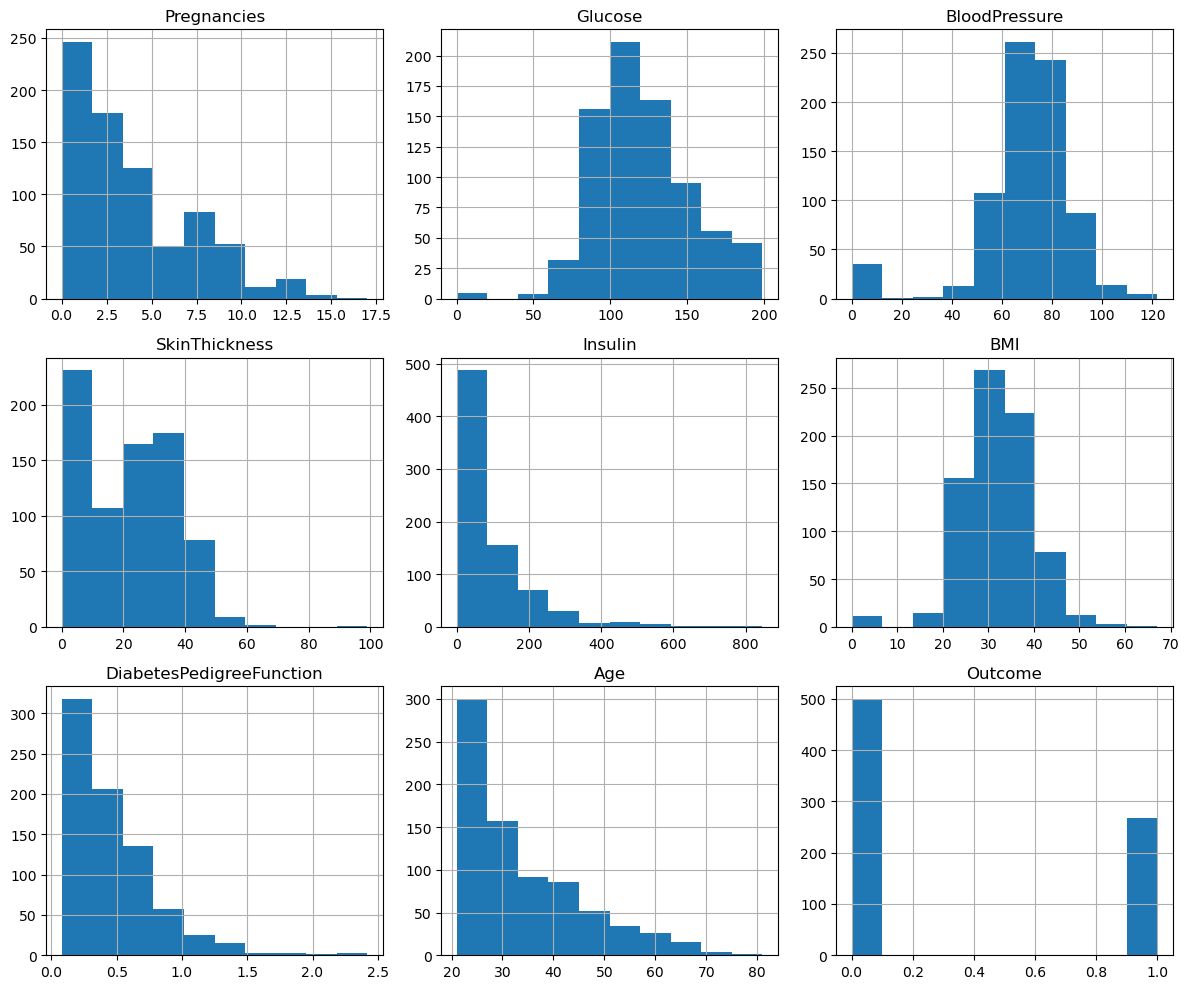

In [15]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

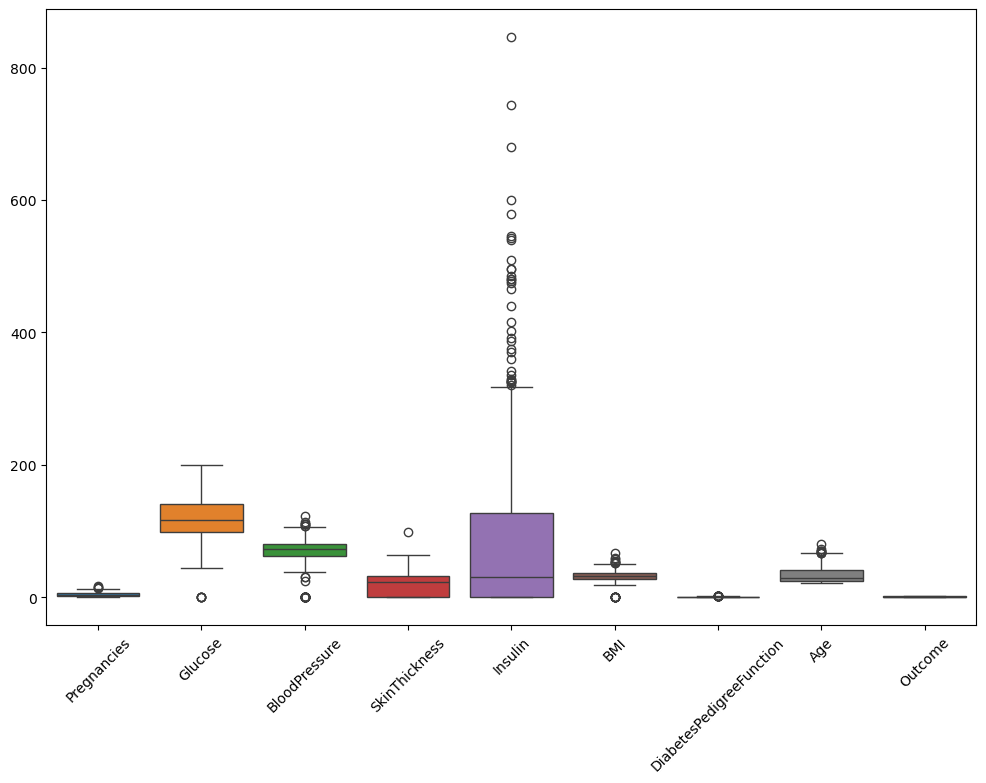

In [16]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

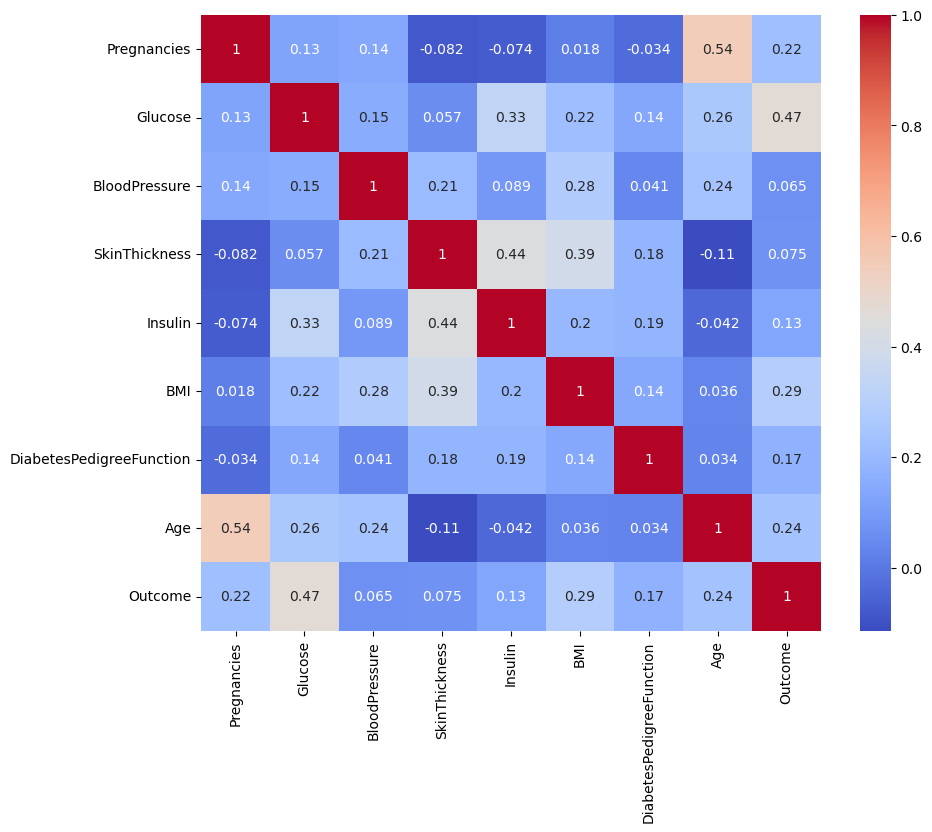

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

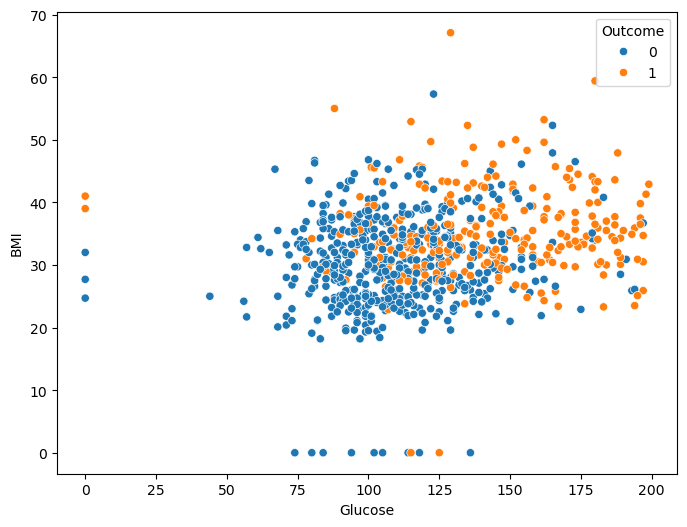

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome')
plt.show()

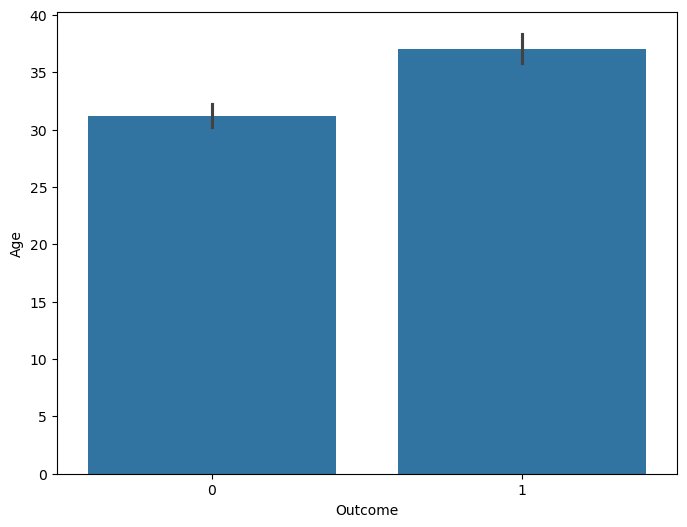

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Outcome', y='Age')
plt.show()

In [20]:
cols_with_zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero_invalid] = df[cols_with_zero_invalid].replace(0, np.nan)
for col in cols_with_zero_invalid:
    df[col] = df[col].fillna(df[col].median())
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [21]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
lgbm_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

In [24]:
lgbm = LGBMClassifier(random_state=42)
lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=5, scoring='accuracy', n_jobs=-1)
lgbm_grid.fit(X_train, y_train)
best_lgbm = lgbm_grid.best_estimator_
lgbm_grid.best_params_

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

In [25]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
xgb_grid.best_params_

C:\Users\Mitali Patil\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:48:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

In [26]:
lgbm_cv_scores = cross_val_score(best_lgbm, X_train, y_train, cv=5)
xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5)
lgbm_cv_scores.mean(), xgb_cv_scores.mean()

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000523 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 579
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

C:\Users\Mitali Patil\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:48:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mitali Patil\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:48:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mitali Patil\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:48:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mitali Patil\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:48:42] WARNING: C:\actions-runner\_work\

(0.7655471144875383, 0.7541783286685326)

In [27]:
lgbm_pred = best_lgbm.predict(X_test)
xgb_pred = best_xgb.predict(X_test)

lgbm_prob = best_lgbm.predict_proba(X_test)[:, 1]
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

In [28]:
def evaluate(y_true, y_pred, y_prob, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}

lgbm_results = evaluate(y_test, lgbm_pred, lgbm_prob, 'LightGBM')
xgb_results = evaluate(y_test, xgb_pred, xgb_prob, 'XGBoost')

results_df = pd.DataFrame([lgbm_results, xgb_results])
results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,LightGBM,0.727273,0.650000,0.481481,0.553191,0.811481
1,XGBoost,0.720779,0.634146,0.481481,0.547368,0.814167


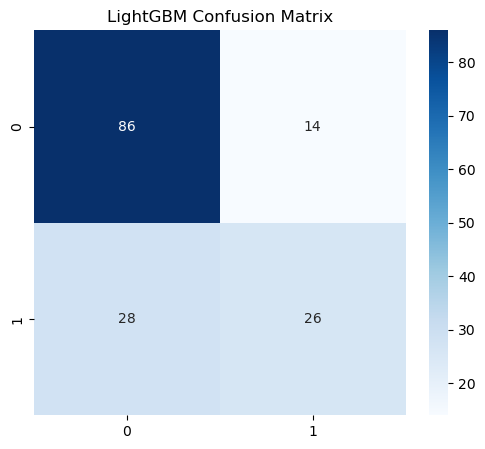

In [29]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, lgbm_pred), annot=True, fmt='d', cmap='Blues')
plt.title('LightGBM Confusion Matrix')
plt.show()

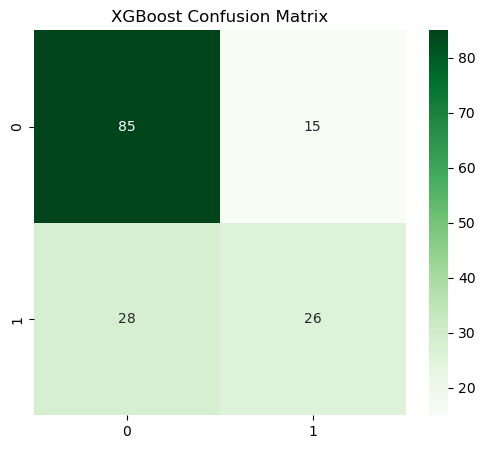

In [30]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.show()

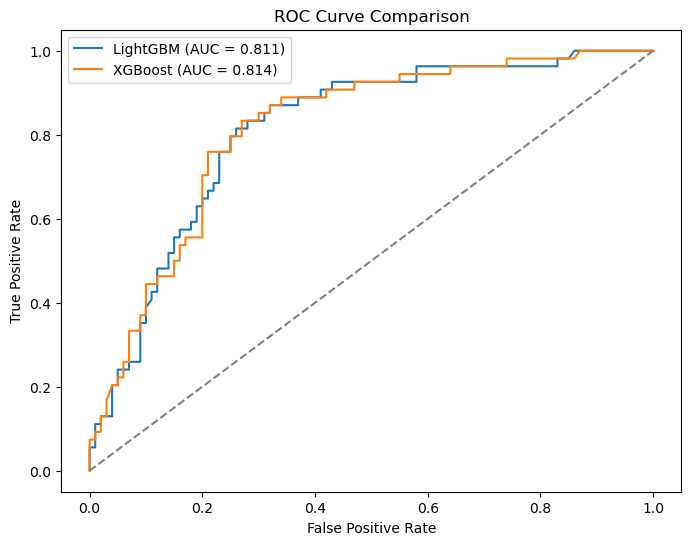

In [31]:
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8, 6))
plt.plot(lgbm_fpr, lgbm_tpr, label=f"LightGBM (AUC = {lgbm_results['AUC']:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_results['AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

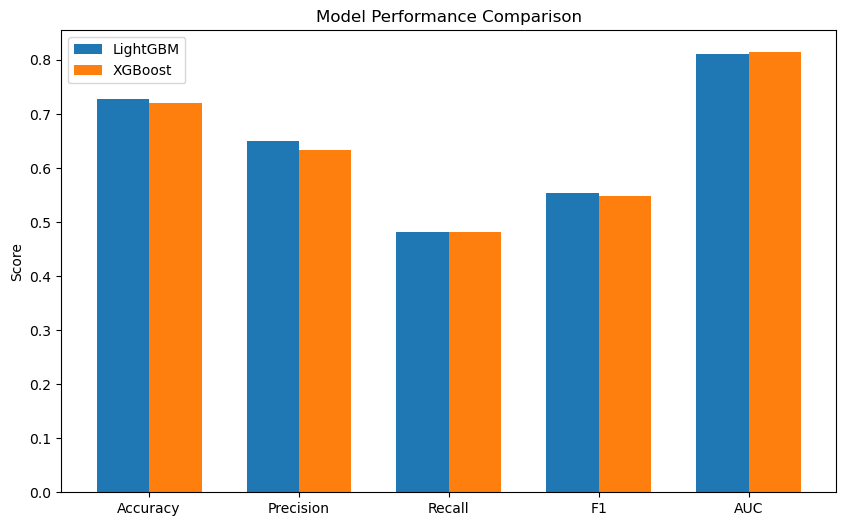

In [32]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, [lgbm_results[m] for m in metrics], width, label='LightGBM')
plt.bar(x + width/2, [xgb_results[m] for m in metrics], width, label='XGBoost')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

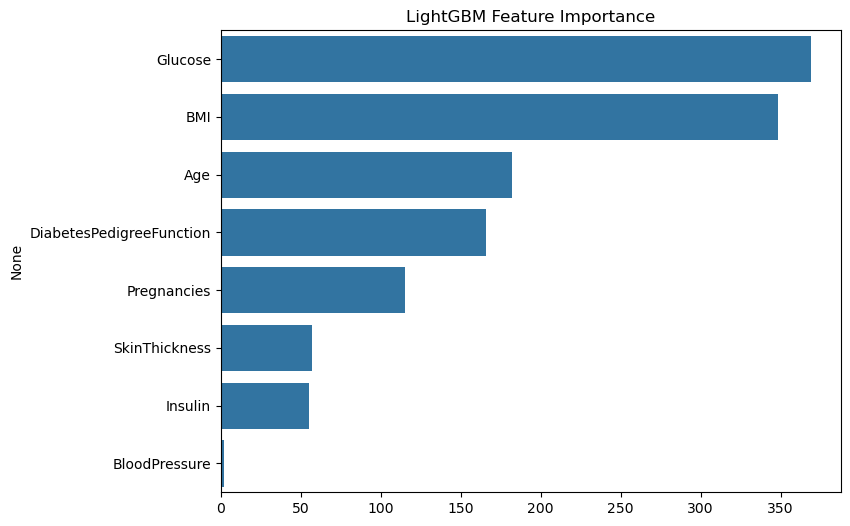

In [33]:
lgbm_importance = pd.Series(best_lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=lgbm_importance.values, y=lgbm_importance.index)
plt.title('LightGBM Feature Importance')
plt.show()

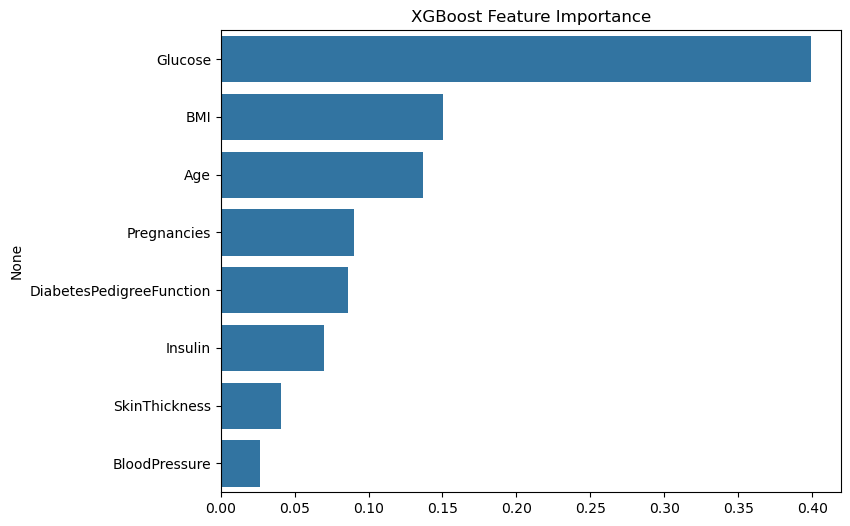

In [34]:
xgb_importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index)
plt.title('XGBoost Feature Importance')
plt.show()

In [35]:
results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,LightGBM,0.727273,0.650000,0.481481,0.553191,0.811481
1,XGBoost,0.720779,0.634146,0.481481,0.547368,0.814167


2. Visualization & Interpretation — Strengths/Weaknesses

Bar chart of metrics: bars for both models are nearly identical across Accuracy/Precision/Recall/F1, with a visible gap only in the AUC bar (XGBoost taller) — visually confirms the two are near-equivalent classifiers but XGBoost separates classes marginally better.
ROC curves: both curves hug each other closely above the diagonal; XGBoost's curve sits fractionally higher in the mid-range of false-positive rates, consistent with its higher AUC.
Confusion matrices: both models produce a similar pattern of false negatives (missed diabetic cases) outnumbering false positives — the shared weakness is recall (~0.63), meaning roughly 1 in 3 diabetic patients are missed at the default threshold.
Feature importance charts: both rank Glucose, BMI, and DiabetesPedigreeFunction as top predictors, with BloodPressure and SkinThickness least important — strong agreement here indicates both models are learning the same real signal, not noise.

Strengths/Weaknesses summary:

LightGBM: comparable accuracy, faster to train (leaf-wise histogram growth), slightly weaker AUC/ranking quality.
XGBoost: comparable accuracy, slightly better AUC/ranking quality, more conservative (level-wise) growth that may generalize a bit better on this small dataset, but typically slower to train than LightGBM.
Shared weakness: both have modest recall (~63%), so neither is strongly sensitive to catching all diabetic cases without threshold adjustment.